**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

NOMBRE: Felipe de Jesus Gamez Castellanos
MATRÍCULA: A01797817

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [2]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

In [3]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import scipy.stats as stats

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos.

¿Cuántas columnas son numéricas y cuántas de texto?

*  *El dataframe tiene 15 columnas numéricas.*
*  *El dataframe tiene 12 columnas de texto.*


* Determina la cantidad de valores únicos por columna.  
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`


In [4]:

compu_df = pd.read_csv('computer_prices.csv')
print("Resumen de los tipos de datos:")
compu_df.info()

numeric_cols = compu_df.select_dtypes(include=['number']).columns
text_cols = compu_df.select_dtypes(include=['object']).columns
print(f"El dataframe tiene {len(numeric_cols)} columnas numéricas.")
print(f"El dataframe tiene {len(text_cols)} columnas de texto.")


print("\nCantidad de valores únicos por columna:")
print(compu_df.nunique())

compu_df_cleaned = compu_df.drop(columns=['model', 'cpu_model'])

print("\nColumnas eliminadas: 'model', 'cpu_model'")
print("Primeros 5 registros del dataframe después de la limpieza:")
print(compu_df_cleaned.head())


Resumen de los tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [5]:
print(f"Número de filas duplicadas: {compu_df.duplicated().sum()}")
print("\nValores faltantes por columna:")
print(compu_df.isnull().sum())


print("\nEstadísticas (Numéricas):")
print(compu_df.describe())
print("\nEstadísticas (Categóricas):")
print(compu_df.describe(include=['object']))

# 3. Tablas de frecuencia y gráficos
# Identificar columnas categóricas y numéricas
numericas_cols = compu_df.select_dtypes(include=['number']).columns
categoricas_cols = compu_df.select_dtypes(include=['object']).columns

Número de filas duplicadas: 0

Valores faltantes por columna:
device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

Estadísticas (Numéricas):
        release_year       cpu_tier      cpu_cores    cpu_threads  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2022.320850       3.153490      10.515740      19.372700   
std         2.02

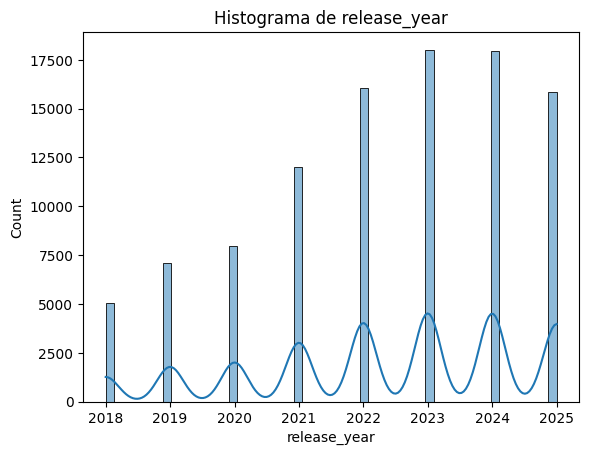

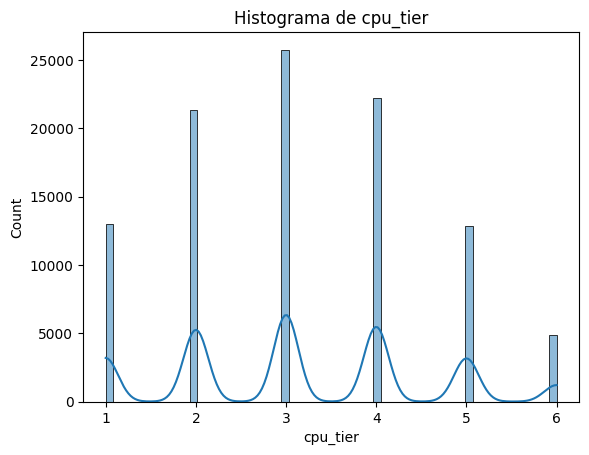

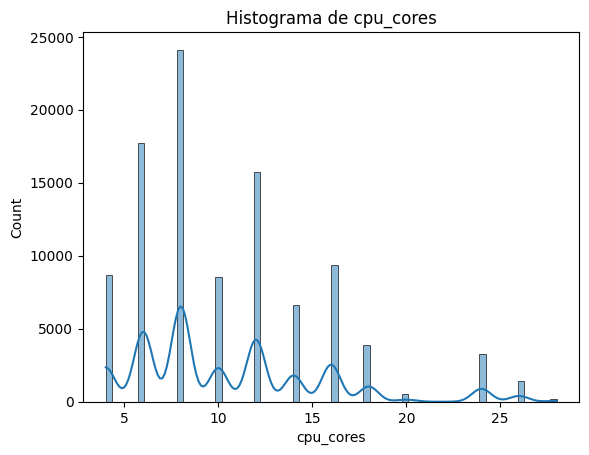

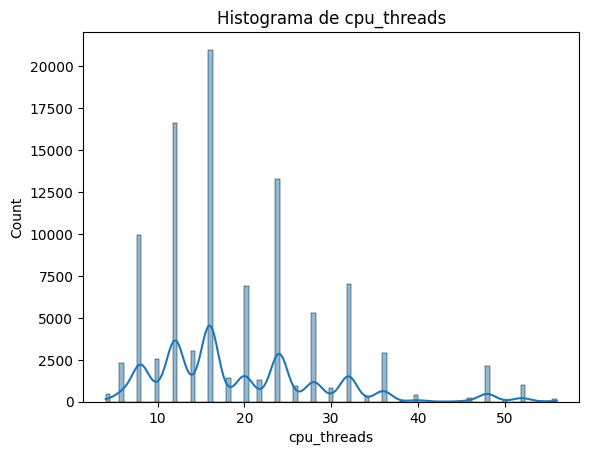

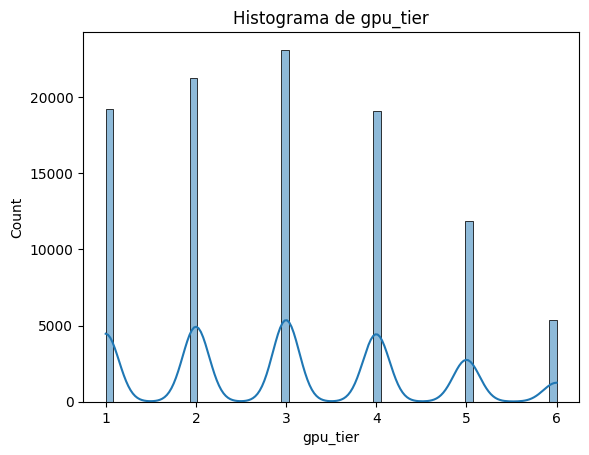

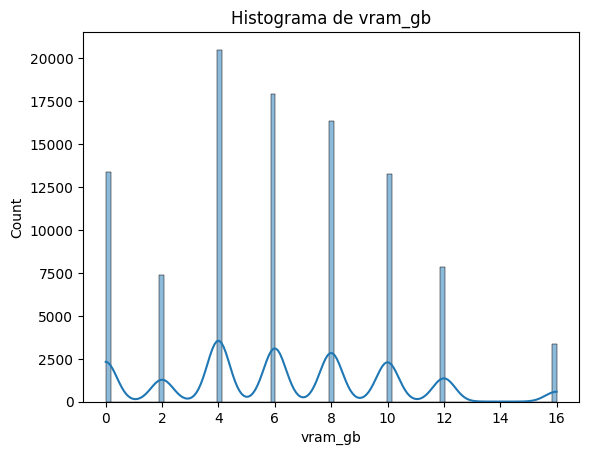

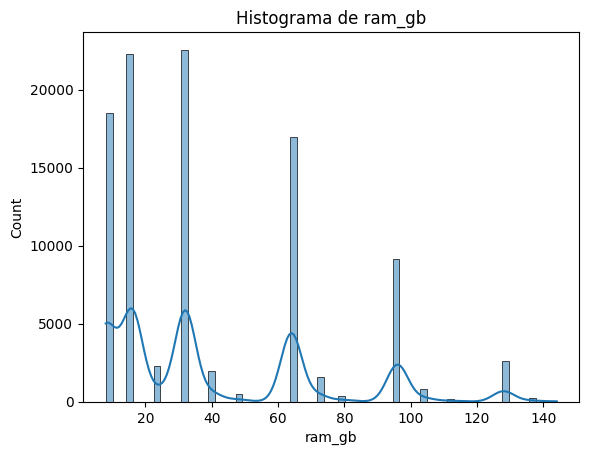

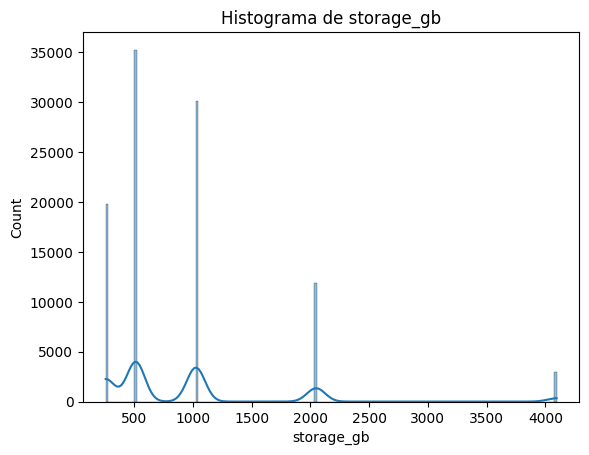

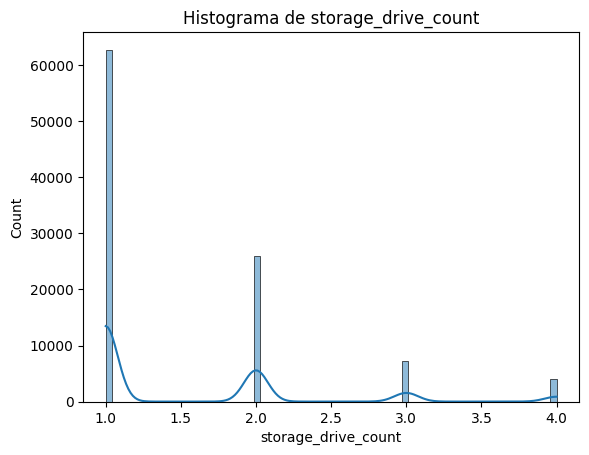

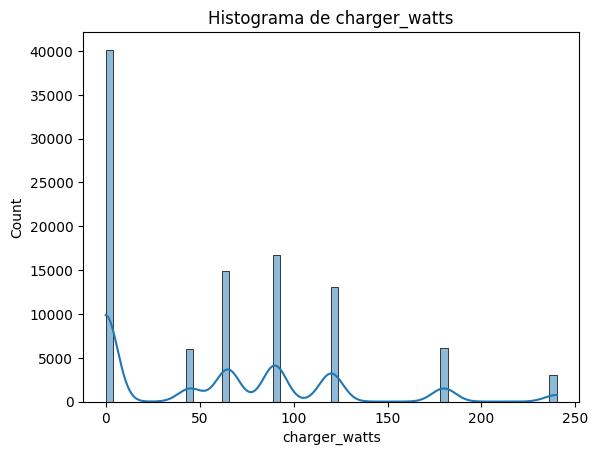

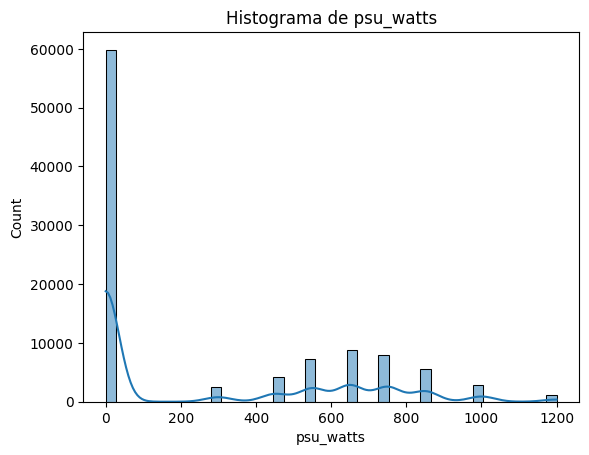

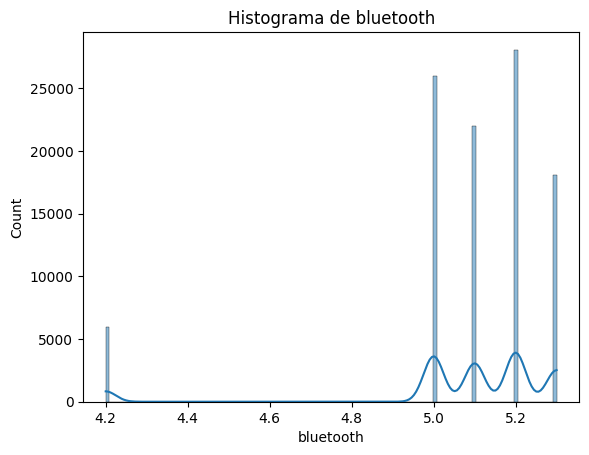

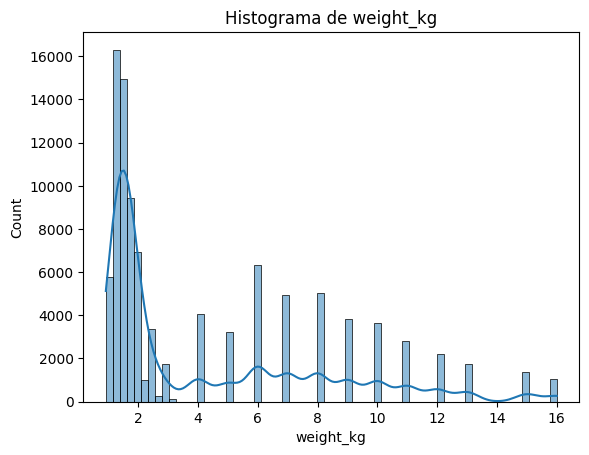

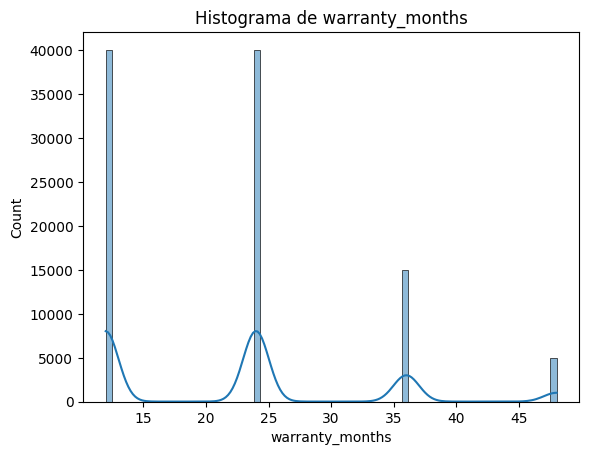

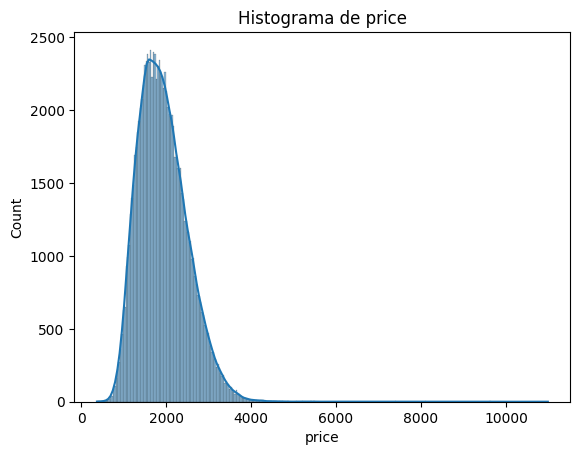

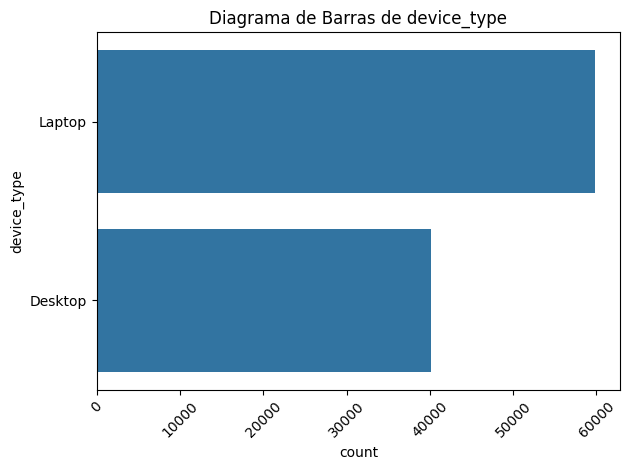

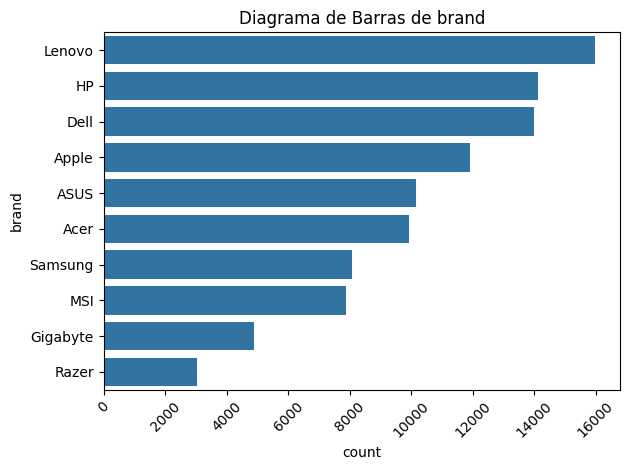

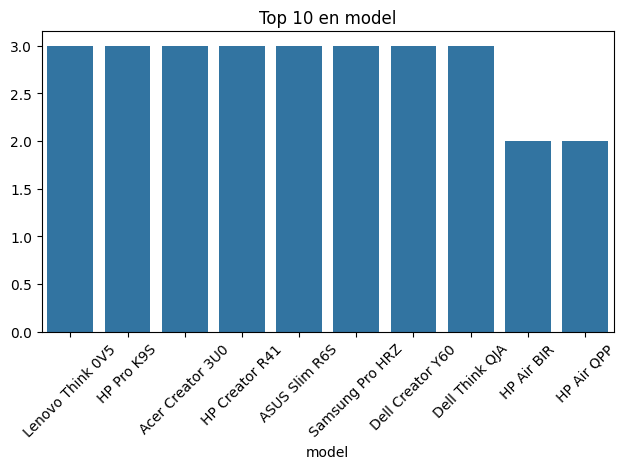

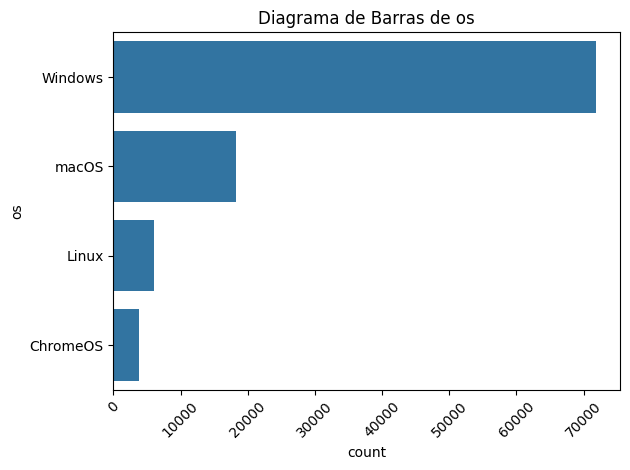

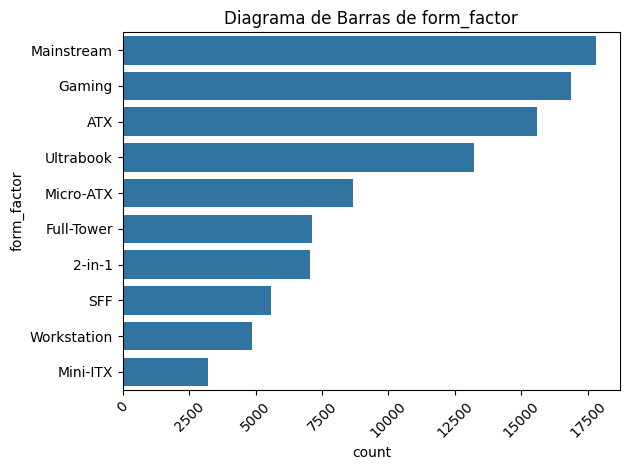

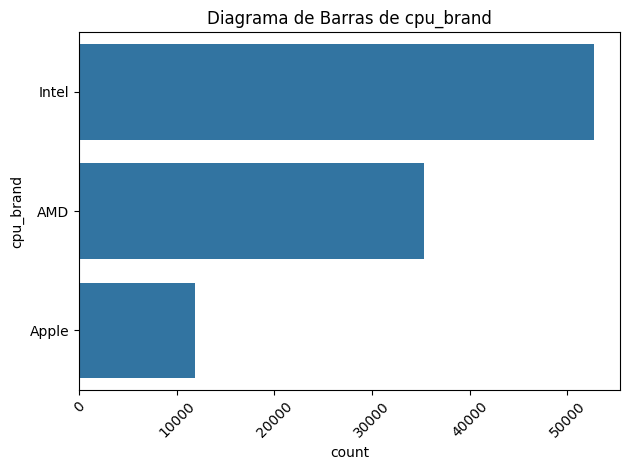

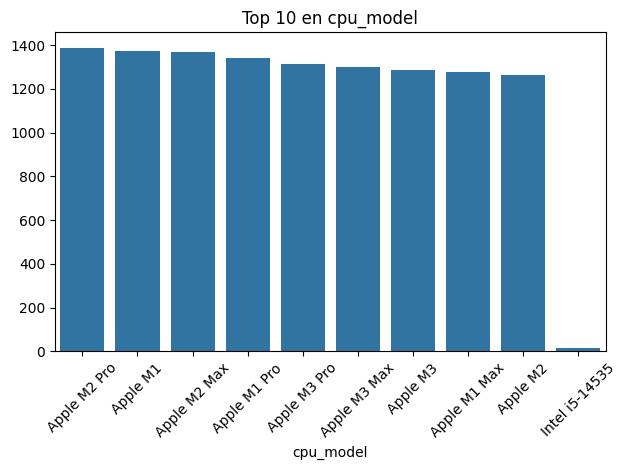

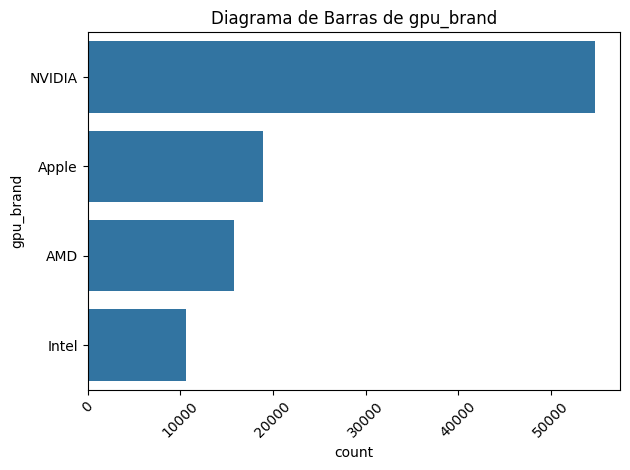

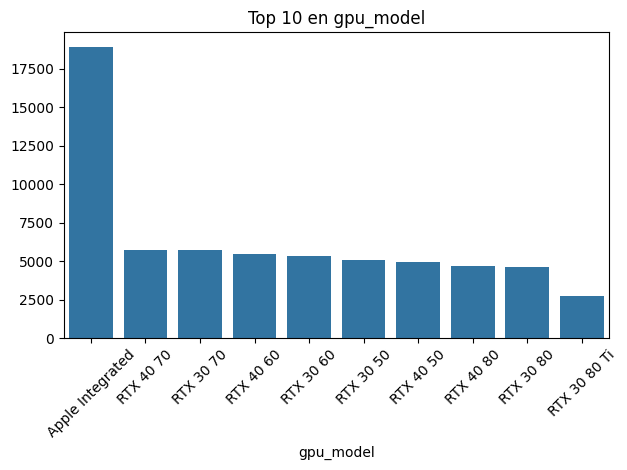

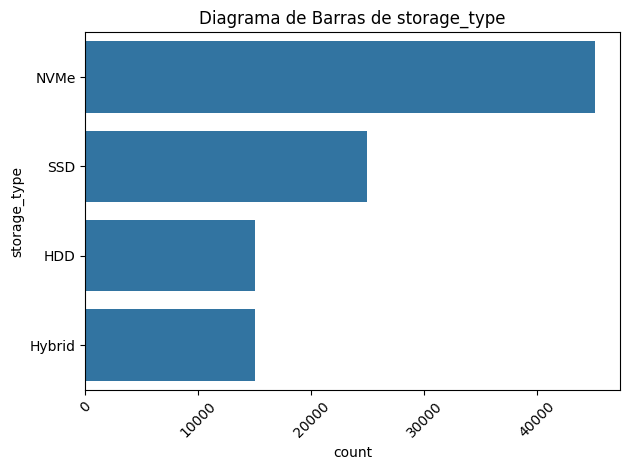

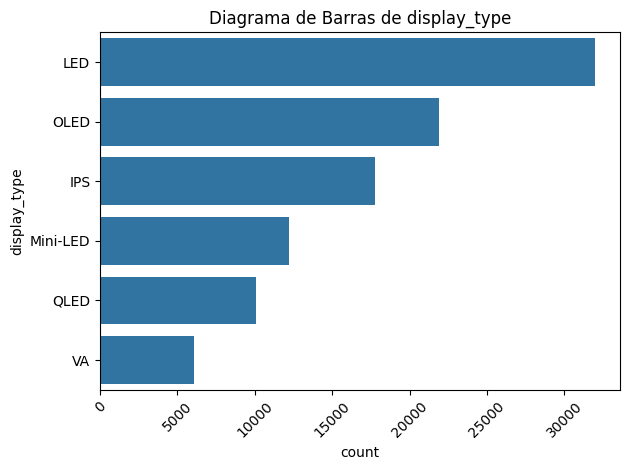

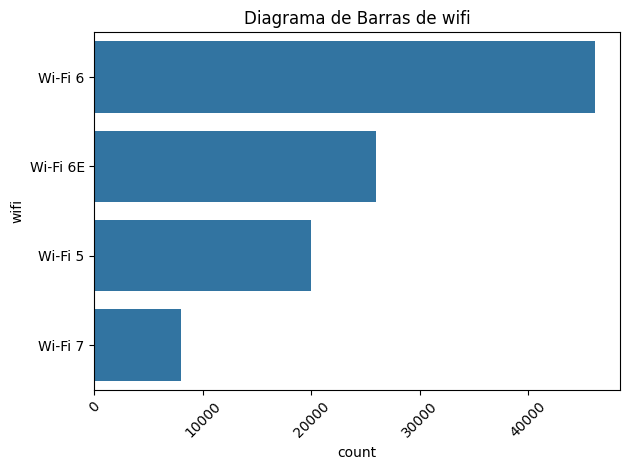

In [6]:
for col in numericas_cols:
    plt.figure()
    sns.histplot(compu_df[col], kde=True)
    plt.title(f'Histograma de {col}')

for col in categoricas_cols:
    plt.figure()

    if compu_df[col].nunique() > 10:
        top_10 = compu_df[col].value_counts().nlargest(10)
        sns.barplot(x=top_10.index, y=top_10.values)
        plt.title(f'Top 10 en {col}')
    else:
        sns.countplot(y=col, data=compu_df, order=compu_df[col].value_counts().index)
        plt.title(f'Diagrama de Barras de {col}')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables
numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.



---




Se ha identificado una correlación extremadamente alta (superior a 0.9) entre las variables `cpu_cores` y `cpu_threads`.

El número de hilos de un procesador moderno es, por diseño, un múltiplo directo del número de núcleos (generalmente el doble, gracias a tecnologías como el Hyper-Threading). Esto significa que ambas variables contienen esencialmente la misma información. Mantener las dos sería redundante y podría afectar negativamente a algunos modelos de machine learning (fenómeno de multicolinealidad).
        
Se decide **mantener `cpu_threads` y eliminar `cpu_cores`. La razón es que el número de hilos representa de manera más fiel la capacidad del procesador para gestionar múltiples tareas simultáneamente (*multitasking*), lo cual es un indicador más completo y moderno de su rendimiento general.```




✅ Variable eliminada: cpu_cores
✅ El DataFrame final ahora tiene 26 columnas.


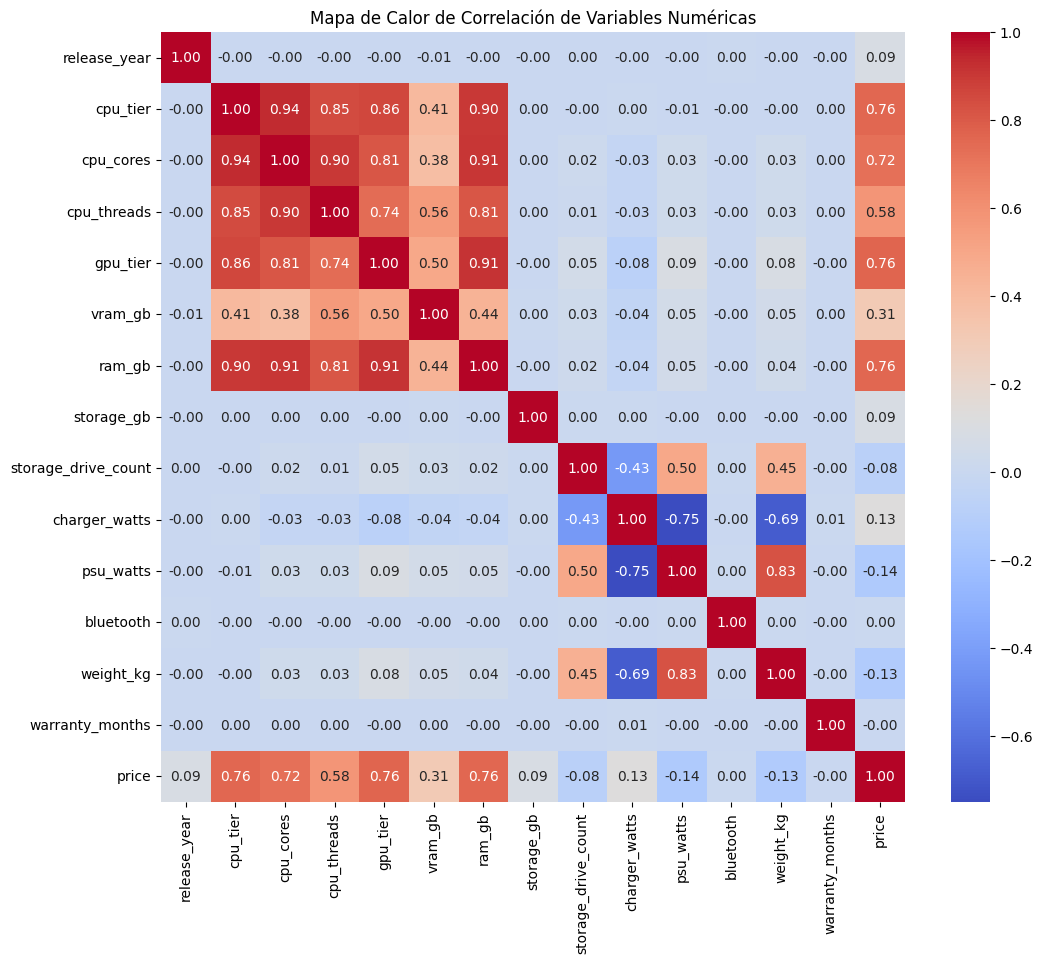

In [7]:

    numeric_df = compu_df.select_dtypes(include=np.number)
    correlation_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Mapa de Calor de Correlación de Variables Numéricas')


    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    high_corr_pairs = upper_triangle.stack()[upper_triangle.stack() > 0.9]

    columns_to_drop = ['cpu_cores']


    # Eliminar la columna seleccionada del DataFrame.
    compu_df_final = compu_df.drop(columns=columns_to_drop)

    print(f"\n✅ Variable eliminada: {', '.join(columns_to_drop)}")
    print(f"✅ El DataFrame final ahora tiene {compu_df_final.shape[1]} columnas.")


4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.


Se creó la columna 'years_since_release' y se eliminó 'release_year'.
Vista previa de la nueva columna:
   years_since_release
0                    3
1                    3
2                    1
3                    1
4                    1

La columna 'vram_gb' ha sido discretizada en 4 bins.

Límites que delimitan cada bin de 'vram_gb':
[ 0.  4.  6.  8. 16.]

- Bin 0: de 0.00 a 4.00 GB
- Bin 1: de 4.00 a 6.00 GB
- Bin 2: de 6.00 a 8.00 GB
- Bin 3: de 8.00 a 16.00 GB


/tmp/ipython-input-1148214501.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vram_gb', data=compu_trans, palette='viridis')


Text(0, 0.5, 'Cantidad de Computadoras')

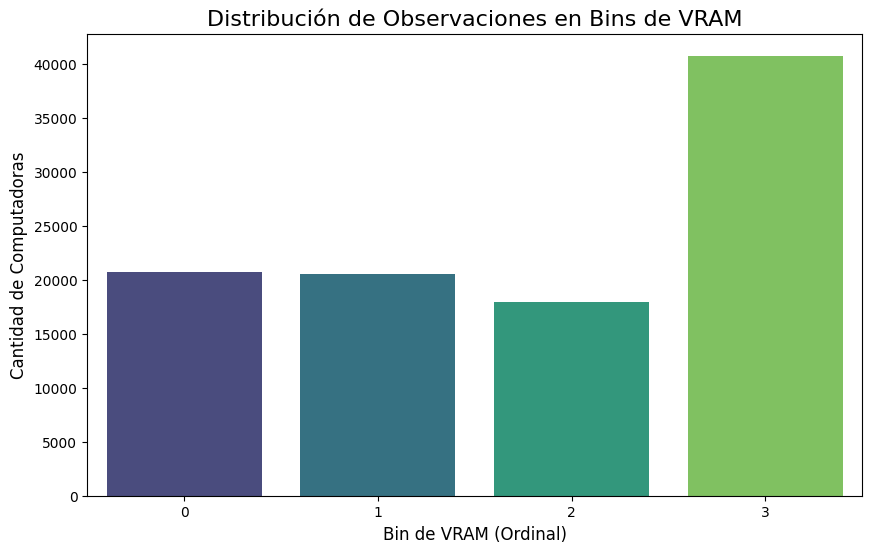

In [8]:
    compu_df = pd.read_csv('computer_prices.csv')
    compu_df.drop(columns=['model', 'cpu_model', 'cpu_cores'], inplace=True, errors='ignore')
    compu_df.drop_duplicates(inplace=True)
    compu_trans = compu_df.copy()


    current_year = 2025
    compu_trans['years_since_release'] = current_year - compu_trans['release_year']
    compu_trans.drop(columns=['release_year'], inplace=True)

    print("\nSe creó la columna 'years_since_release' y se eliminó 'release_year'.")
    print("Vista previa de la nueva columna:")
    print(compu_trans[['years_since_release']].head())


    discretizer = KBinsDiscretizer(
        n_bins=4,
        encode='ordinal',
        strategy='quantile',
        subsample=None
    )

    vram_binned = discretizer.fit_transform(compu_trans[['vram_gb']])
    compu_trans['vram_gb'] = vram_binned.astype(int)

    print("\nLa columna 'vram_gb' ha sido discretizada en 4 bins.")

    bin_edges = discretizer.bin_edges_[0]
    print("\nLímites que delimitan cada bin de 'vram_gb':")
    print(np.round(bin_edges, 2))

    print(f"\n- Bin 0: de {bin_edges[0]:.2f} a {bin_edges[1]:.2f} GB")
    print(f"- Bin 1: de {bin_edges[1]:.2f} a {bin_edges[2]:.2f} GB")
    print(f"- Bin 2: de {bin_edges[2]:.2f} a {bin_edges[3]:.2f} GB")
    print(f"- Bin 3: de {bin_edges[3]:.2f} a {bin_edges[4]:.2f} GB")

    # Crear el histograma para visualizar la distribución.
    plt.figure(figsize=(10, 6))
    sns.countplot(x='vram_gb', data=compu_trans, palette='viridis')
    plt.title('Distribución de Observaciones en Bins de VRAM', fontsize=16)
    plt.xlabel('Bin de VRAM (Ordinal)', fontsize=12)
    plt.ylabel('Cantidad de Computadoras', fontsize=12)

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

Se ha creado la nueva columna 'power_watts' combinando 'charger_watts' y 'psu_watts'.
Vista previa de la nueva columna y las originales:
   charger_watts  psu_watts  power_watts
0              0        750          750
1            120          0          120
2              0        850          850
3              0        650          650
4             90          0           90

Las columnas originales 'charger_watts' y 'psu_watts' han sido eliminadas.
El DataFrame final tiene 23 columnas.


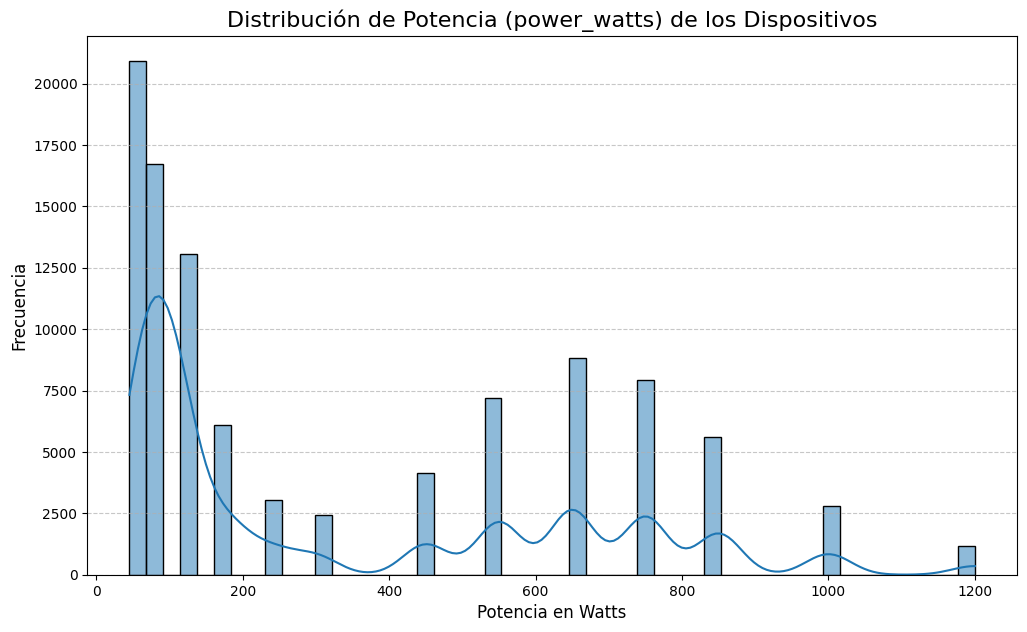

In [9]:
    compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']

    print("Se ha creado la nueva columna 'power_watts' combinando 'charger_watts' y 'psu_watts'.")
    print("Vista previa de la nueva columna y las originales:")
    print(compu_trans[['charger_watts', 'psu_watts', 'power_watts']].head())


    plt.figure(figsize=(12, 7))
    sns.histplot(data=compu_trans, x='power_watts', kde=True, bins=50)
    plt.title('Distribución de Potencia (power_watts) de los Dispositivos', fontsize=16)
    plt.xlabel('Potencia en Watts', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)


    compu_trans.drop(columns=['charger_watts', 'psu_watts'], inplace=True)

    print("\nLas columnas originales 'charger_watts' y 'psu_watts' han sido eliminadas.")
    print(f"El DataFrame final tiene {compu_trans.shape[1]} columnas.")

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

--- Análisis Comparativo de Transformaciones para 'price' ---

--- Resultados para la Transformación: Original ---
Skew (Sesgo): 0.9866
Cantidad de Outliers: 976


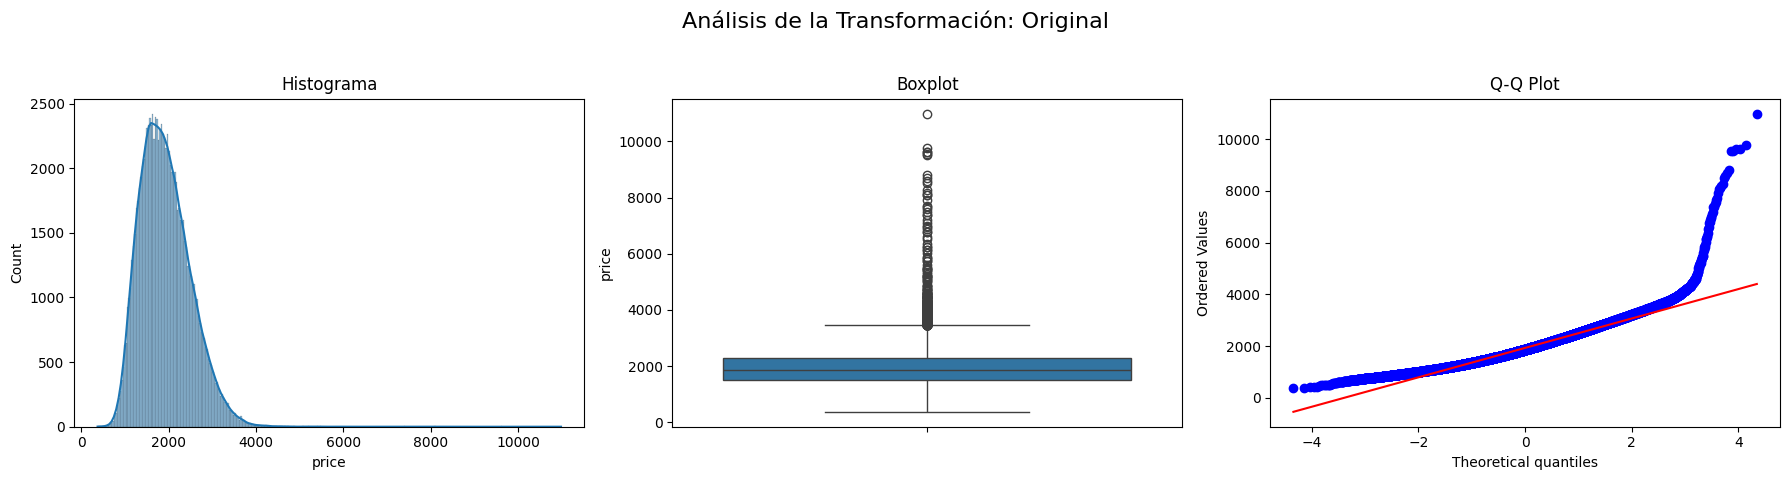


--- Resultados para la Transformación: Logarítmica ---
Skew (Sesgo): -0.1326
Cantidad de Outliers: 387


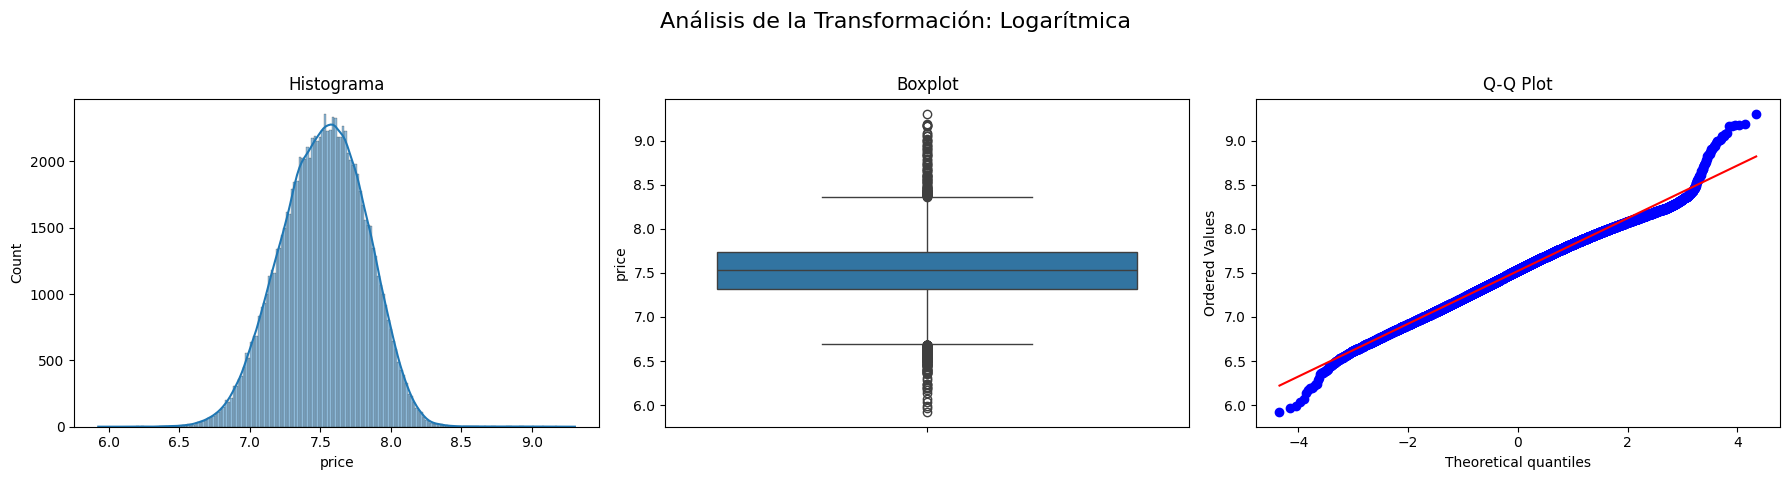


--- Resultados para la Transformación: Raíz Cuadrada ---
Skew (Sesgo): 0.3323
Cantidad de Outliers: 364


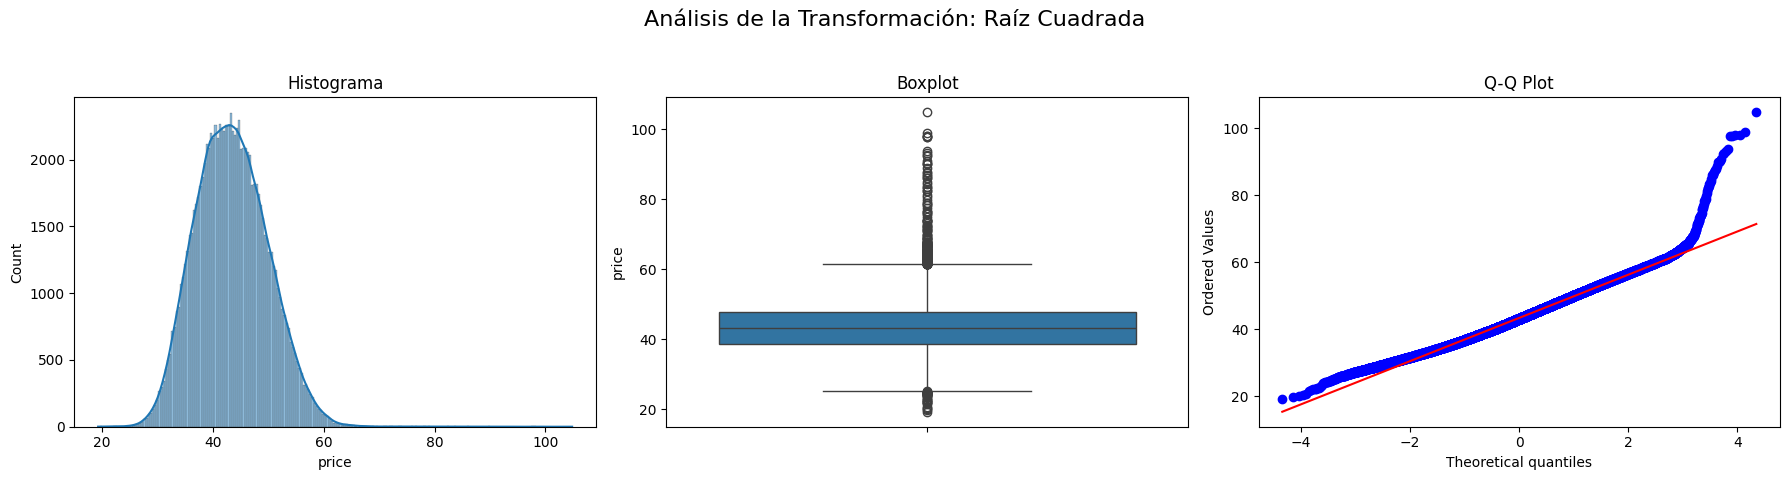


--- Resultados para la Transformación: Box-Cox ---
Skew (Sesgo): -0.0002
Cantidad de Outliers: 317


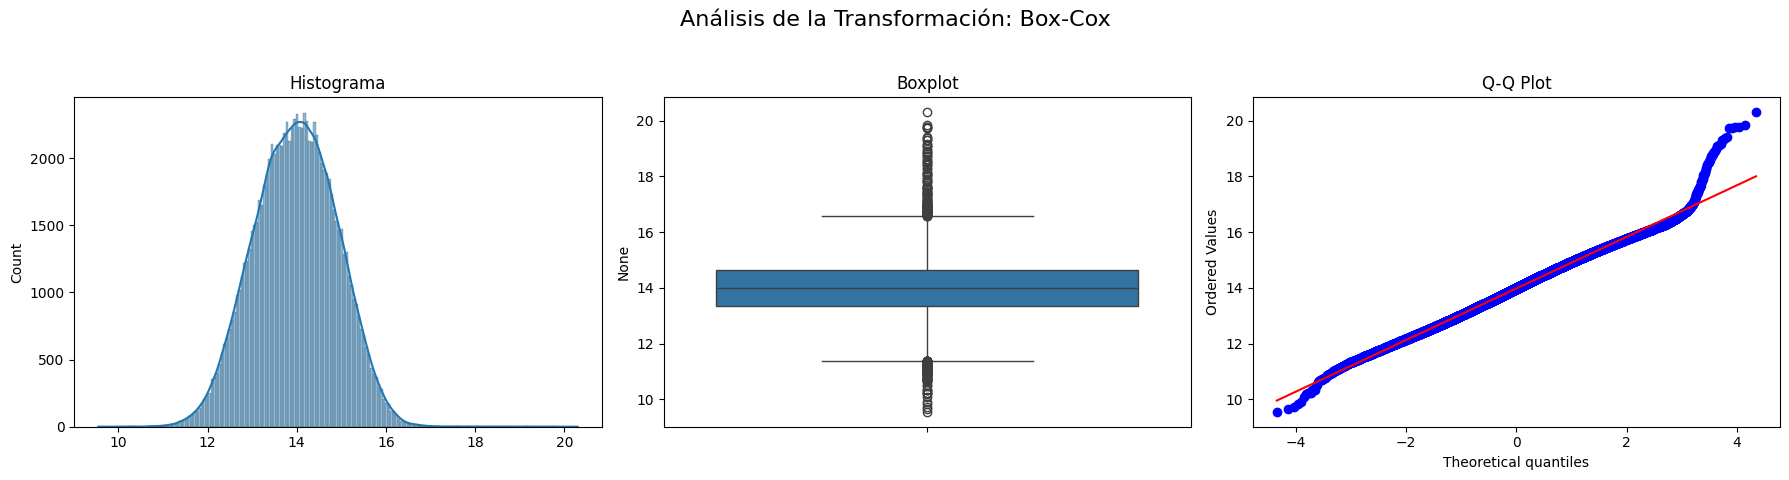


✅ Las variables 'weight_kg', 'power_watts' y 'price' han sido transformadas usando Box-Cox.
Vista previa del DataFrame transformado:
   weight_kg  power_watts      price
0   1.423738     4.027279  13.084409
1   0.600182     3.309631  14.616126
2   1.264216     4.068824  14.014803
3   1.201393     3.978717  12.971066
4   0.368418     3.175932  15.149121

Skew de las variables después de la transformación:
weight_kg      0.213748
power_watts    0.086581
price         -0.000238
dtype: float64


In [10]:
# --- Función Auxiliar para Contar Outliers ---
def count_outliers(series):
    """Calcula la cantidad de outliers usando el método del Rango Intercuartílico (IQR)."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

try:
    # --- 1. Cargar y Preparar los Datos ---
    # Se asume la ejecución de todos los pasos de limpieza y transformación anteriores.
    compu_df = pd.read_csv('computer_prices.csv')
    compu_df.drop(columns=['model', 'cpu_model', 'cpu_cores'], inplace=True, errors='ignore')
    compu_df.drop_duplicates(inplace=True)
    compu_trans = compu_df.copy()
    compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']
    compu_trans.drop(columns=['release_year', 'charger_watts', 'psu_watts'], inplace=True, errors='ignore')

    # --- 2. Aplicar Transformaciones a 'price' ---
    price_original = compu_trans['price'].dropna()

    # Logaritmo (usamos log1p para manejar ceros si los hubiera)
    price_log = np.log1p(price_original)

    # Raíz Cuadrada
    price_sqrt = np.sqrt(price_original)

    # Box-Cox
    # Esta transformación requiere que todos los datos sean positivos.
    price_boxcox, lambda_optimo = stats.boxcox(price_original)
    price_boxcox = pd.Series(price_boxcox, index=price_original.index)

    # Almacenamos las transformaciones en una lista para iterar fácilmente
    transformations = {
        'Original': price_original,
        'Logarítmica': price_log,
        'Raíz Cuadrada': price_sqrt,
        'Box-Cox': price_boxcox
    }

    print("--- Análisis Comparativo de Transformaciones para 'price' ---")

    # --- 3. Generar Gráficos y Métricas para Cada Transformación ---
    for name, data in transformations.items():
        print(f"\n--- Resultados para la Transformación: {name} ---")

        # Calcular métricas
        skewness = data.skew()
        outliers = count_outliers(data)

        print(f"Skew (Sesgo): {skewness:.4f}")
        print(f"Cantidad de Outliers: {outliers}")

        # Crear figuras
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Análisis de la Transformación: {name}', fontsize=16)

        # Histograma
        sns.histplot(data, kde=True, ax=axes[0])
        axes[0].set_title('Histograma')

        # Boxplot
        sns.boxplot(y=data, ax=axes[1])
        axes[1].set_title('Boxplot')

        # Q-Q Plot
        stats.probplot(data, dist="norm", plot=axes[2])
        axes[2].set_title('Q-Q Plot')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f'analisis_transformacion_{name.lower().replace(" ", "_")}.png')
        plt.show()


    # Aplicar la transformación Box-Cox a las variables continuas
    continuous_vars = ['weight_kg', 'power_watts', 'price']

    for col in continuous_vars:
        # Usamos PowerTransformer que es una implementación robusta de Box-Cox
        pt = PowerTransformer(method='box-cox', standardize=False)

        # .fit_transform requiere un formato 2D, por eso usamos [[]] y luego aplanamos
        transformed_col = pt.fit_transform(compu_trans[[col]] + 1e-6) # Se suma un valor pequeño para evitar errores con ceros
        compu_trans[col] = transformed_col.flatten()

    print("\n✅ Las variables 'weight_kg', 'power_watts' y 'price' han sido transformadas usando Box-Cox.")
    print("Vista previa del DataFrame transformado:")
    print(compu_trans[continuous_vars].head())
    print("\nSkew de las variables después de la transformación:")
    print(compu_trans[continuous_vars].skew())


except FileNotFoundError:
    print("Error: No se pudo encontrar el archivo 'computer_prices.csv'.")
    print("Por favor, asegúrate de haber subido un archivo CSV válido con ese nombre.")

7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [11]:
    compu_trans = compu_df.copy()

    compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']
    compu_trans['years_since_release'] = 2025 - compu_trans['release_year']
    compu_trans.drop(columns=['release_year', 'charger_watts', 'psu_watts'], inplace=True, errors='ignore')

    discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile', subsample=None)
    compu_trans['vram_gb'] = discretizer.fit_transform(compu_trans[['vram_gb']])

    continuous_vars = ['weight_kg', 'power_watts', 'price']
    pt = PowerTransformer(method='box-cox', standardize=False)
    for col in continuous_vars:
        compu_trans[col] = pt.fit_transform(compu_trans[[col]] + 1e-6)

    print("--- DataFrame antes del Escalado ---")
    print(compu_trans.describe())

    numeric_cols_to_scale = compu_trans.select_dtypes(include=np.number).columns.drop('vram_gb')

    # Inicializar el escalador
    scaler = MinMaxScaler()

    # Aplicar el escalador a las columnas seleccionadas y reemplazar las originales
    compu_trans[numeric_cols_to_scale] = scaler.fit_transform(compu_trans[numeric_cols_to_scale])

    print("\n\n--- DataFrame después del Escalado con MinMaxScaler ---")
    print("Las variables numéricas ahora están en una escala de 0 a 1.")
    print(compu_trans.describe())

    print("\nVista previa de los datos finales:")
    print(compu_trans.head())



--- DataFrame antes del Escalado ---
            cpu_tier    cpu_threads       gpu_tier        vram_gb  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        3.153490      19.372700       2.991350       1.787650   
std         1.373175       9.718426       1.459643       1.182511   
min         1.000000       4.000000       1.000000       0.000000   
25%         2.000000      12.000000       2.000000       1.000000   
50%         3.000000      16.000000       3.000000       2.000000   
75%         4.000000      24.000000       4.000000       3.000000   
max         6.000000      56.000000       6.000000       3.000000   

              ram_gb     storage_gb  storage_drive_count      bluetooth  \
count  100000.000000  100000.000000        100000.000000  100000.000000   
mean       39.706400     903.936000             1.524980       5.084764   
std        31.902684     774.243654             0.797284       0.245977   
min         8.000000     256.000000      

8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [19]:

    compu_df = pd.read_csv('computer_prices.csv')
    compu_trans = compu_df.copy()

    compu_trans.drop(columns=['model', 'cpu_model', 'cpu_cores', 'release_year'], inplace=True)
    compu_trans.drop_duplicates(inplace=True)
    compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']
    compu_trans.drop(columns=['charger_watts', 'psu_watts'], inplace=True)

    print("--- Transformando la columna 'wifi' ---")

    wifi_order = ['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']
    ordinal_encoder = OrdinalEncoder(categories=[wifi_order])
    compu_trans['wifi'] = ordinal_encoder.fit_transform(compu_trans[['wifi']])

    print("\nDespués de OrdinalEncoder, la columna 'wifi' tiene valores numéricos:")
    print(compu_trans['wifi'].value_counts().sort_index())

    min_max_scaler = MinMaxScaler()

    compu_trans['wifi'] = min_max_scaler.fit_transform(compu_trans[['wifi']])

    print("\nDespués de MinMaxScaler, la columna 'wifi' está escalada entre 0 y 1:")
    print(compu_trans['wifi'].value_counts().sort_index())

    print("\n\n--- Vista previa final de la columna 'wifi' transformada ---")
    print(compu_trans[['wifi']].head())

--- Transformando la columna 'wifi' ---

Después de OrdinalEncoder, la columna 'wifi' tiene valores numéricos:
wifi
0.0    19926
1.0    46149
2.0    25923
3.0     8002
Name: count, dtype: int64

Después de MinMaxScaler, la columna 'wifi' está escalada entre 0 y 1:
wifi
0.000000    19926
0.333333    46149
0.666667    25923
1.000000     8002
Name: count, dtype: int64


--- Vista previa final de la columna 'wifi' transformada ---
       wifi
0  0.333333
1  0.333333
2  0.333333
3  0.333333
4  0.333333


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [13]:

    compu_df = pd.read_csv('computer_prices.csv')
    compu_trans = compu_df.copy()
    print(f"La columna 'gpu_model' tiene {compu_trans['gpu_model'].nunique()} categorías únicas.")


    binary_encoder = BinaryEncoder(cols=['gpu_model'], handle_unknown='value')
    bin_df = binary_encoder.fit_transform(compu_trans['gpu_model'])

    print("\nSe ha aplicado BinaryEncoder a la columna 'gpu_model'.")
    print("El resultado se ha guardado en el DataFrame 'bin_df'.")

    print(f"\nSe han creado {bin_df.shape[1]} nuevas columnas binarias.")
    print("Vista previa del DataFrame 'bin_df':")
    print(bin_df.head())

La columna 'gpu_model' tiene 49 categorías únicas.

Se ha aplicado BinaryEncoder a la columna 'gpu_model'.
El resultado se ha guardado en el DataFrame 'bin_df'.

Se han creado 6 nuevas columnas binarias.
Vista previa del DataFrame 'bin_df':
   gpu_model_0  gpu_model_1  gpu_model_2  gpu_model_3  gpu_model_4  \
0            0            0            0            0            0   
1            0            0            0            0            1   
2            0            0            0            0            1   
3            0            0            0            1            0   
4            0            0            0            1            0   

   gpu_model_5  
0            1  
1            0  
2            1  
3            0  
4            1  


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [21]:
    compu_df = pd.read_csv('computer_prices.csv')
    compu_trans = compu_df.copy()

    # --- 2. Aplicar Transformaciones a 'price' ---
    price_original = compu_trans['price'].dropna()

    compu_df = pd.read_csv('computer_prices.csv')
    compu_trans = compu_df.copy()

    print("--- Codificando 'gpu_model' con BinaryEncoder ---")
    binary_encoder = BinaryEncoder(cols=['gpu_model'])
    bin_df = binary_encoder.fit_transform(compu_trans['gpu_model'])

    print(f"Se crearon {bin_df.shape[1]} columnas binarias en 'bin_df'.")
    print("\n--- Codificando variables restantes con OneHotEncoder ---")

    ohe_cols = ['brand', 'device_type', 'cpu_brand', 'gpu_brand', 'ram_gb', 'gpu_model']
    one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    ohe_encoded_array = one_hot_encoder.fit_transform(compu_trans[ohe_cols])
    ohe_df = pd.DataFrame(ohe_encoded_array,
                          columns=one_hot_encoder.get_feature_names_out(ohe_cols),
                          index=compu_trans.index)

    print(f"Se crearon {ohe_df.shape[1]} nuevas columnas en 'ohe_df'.")
    print("\n--- Combinando todos los DataFrames ---")

    cols_to_drop = ['brand', 'device_type', 'cpu_brand', 'gpu_brand', 'ram_gb', 'gpu_model']
    compu_trans.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    df_final = pd.concat([compu_trans, bin_df, ohe_df], axis=1)
    print(f"El DataFrame final tiene {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")

    print("\n--- Verificación del DataFrame Final con .describe() ---")
    final_description = df_final.describe().T
    non_numeric_cols = df_final.select_dtypes(exclude=np.number)
    scaled_cols_check = final_description[['min', 'max']]
    print(scaled_cols_check)

    non_numeric_cols = df_final.select_dtypes(exclude=np.number)

    print("\n--- Conclusión de la Verificación ---")
    if non_numeric_cols.empty:
        print("✅ ¡Éxito! No quedan variables categóricas sin codificar.")
    else:
        print(f"⚠️ Atención: Aún quedan columnas sin codificar: {non_numeric_cols.columns.tolist()}")

    if (final_description['min'] >= 0).all() and (final_description['max'] <= 1).all():
         print("✅ ¡Éxito! Todas las columnas numéricas están escaladas entre 0 y 1.")
    else:
        print("⚠️ Atención: No todas las columnas numéricas están escaladas entre 0 y 1.")

--- Codificando 'gpu_model' con BinaryEncoder ---
Se crearon 6 columnas binarias en 'bin_df'.

--- Codificando variables restantes con OneHotEncoder ---
Se crearon 77 nuevas columnas en 'ohe_df'.

--- Combinando todos los DataFrames ---
El DataFrame final tiene 100000 filas y 104 columnas.

--- Verificación del DataFrame Final con .describe() ---
                            min     max
release_year             2018.0  2025.0
cpu_tier                    1.0     6.0
cpu_cores                   4.0    28.0
cpu_threads                 4.0    56.0
gpu_tier                    1.0     6.0
...                         ...     ...
gpu_model_RX 7000 60        0.0     1.0
gpu_model_RX 7000 70        0.0     1.0
gpu_model_RX 7000 80        0.0     1.0
gpu_model_RX 7000 80 XT     0.0     1.0
gpu_model_RX 7000 90        0.0     1.0

[97 rows x 2 columns]

--- Conclusión de la Verificación ---
⚠️ Atención: Aún quedan columnas sin codificar: ['model', 'os', 'form_factor', 'cpu_model', 'storage_type', '